In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('../Datasets/restaurant_orders.csv')
data

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time
0,2268,Mary Vega DDS,Pasta,Main,5,16.52,Cash,2025-02-02 14:28:41
1,3082,Brandon Myers,Brownie,Dessert,4,17.27,Debit Card,2025-06-08 10:57:47
2,3160,Margaret Wells,Pasta,Main,1,3.37,Credit Card,2025-03-04 07:41:41
3,1272,Michael Matthews,Pasta,Main,5,2.20,Online Payment,2025-05-15 12:43:45
4,9447,Connor Williams,Soup,Starter,1,12.23,Cash,2025-03-15 14:25:56
...,...,...,...,...,...,...,...,...
495,6323,Alyssa Anthony,Pizza,Main,1,21.31,Cash,2025-01-15 19:21:02
496,9836,Jerry Pineda,Soup,Starter,3,15.99,Debit Card,2025-07-15 15:00:19
497,1202,Brandy Smith,Pasta,Main,2,8.54,Credit Card,2025-08-03 23:47:28
498,7876,Ivan Haynes,Soup,Starter,5,20.54,Credit Card,2025-07-23 08:10:06


In [3]:
data.isnull().sum()

Order ID          0
Customer Name     0
Food Item         0
Category          0
Quantity          0
Price             0
Payment Method    0
Order Time        0
dtype: int64

In [4]:
data['Price'] = data['Price'].round().astype(int)
data

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time
0,2268,Mary Vega DDS,Pasta,Main,5,17,Cash,2025-02-02 14:28:41
1,3082,Brandon Myers,Brownie,Dessert,4,17,Debit Card,2025-06-08 10:57:47
2,3160,Margaret Wells,Pasta,Main,1,3,Credit Card,2025-03-04 07:41:41
3,1272,Michael Matthews,Pasta,Main,5,2,Online Payment,2025-05-15 12:43:45
4,9447,Connor Williams,Soup,Starter,1,12,Cash,2025-03-15 14:25:56
...,...,...,...,...,...,...,...,...
495,6323,Alyssa Anthony,Pizza,Main,1,21,Cash,2025-01-15 19:21:02
496,9836,Jerry Pineda,Soup,Starter,3,16,Debit Card,2025-07-15 15:00:19
497,1202,Brandy Smith,Pasta,Main,2,9,Credit Card,2025-08-03 23:47:28
498,7876,Ivan Haynes,Soup,Starter,5,21,Credit Card,2025-07-23 08:10:06


In [5]:
food = data['Food Item'].value_counts().reset_index()
food.columns = ['food', 'count']
food

,food,count
0,Pizza,68
1,Brownie,63
2,Fries,60
3,Salad,55
4,Cake,53
5,Ice Cream,52
6,Burger,51
7,Soup,50
8,Pasta,48


C:\Users\sho_taso\AppData\Local\Temp\ipykernel_6704\1704680491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = food['count'], y=food['food'], palette='rocket')


<function matplotlib.pyplot.show(close=None, block=None)>

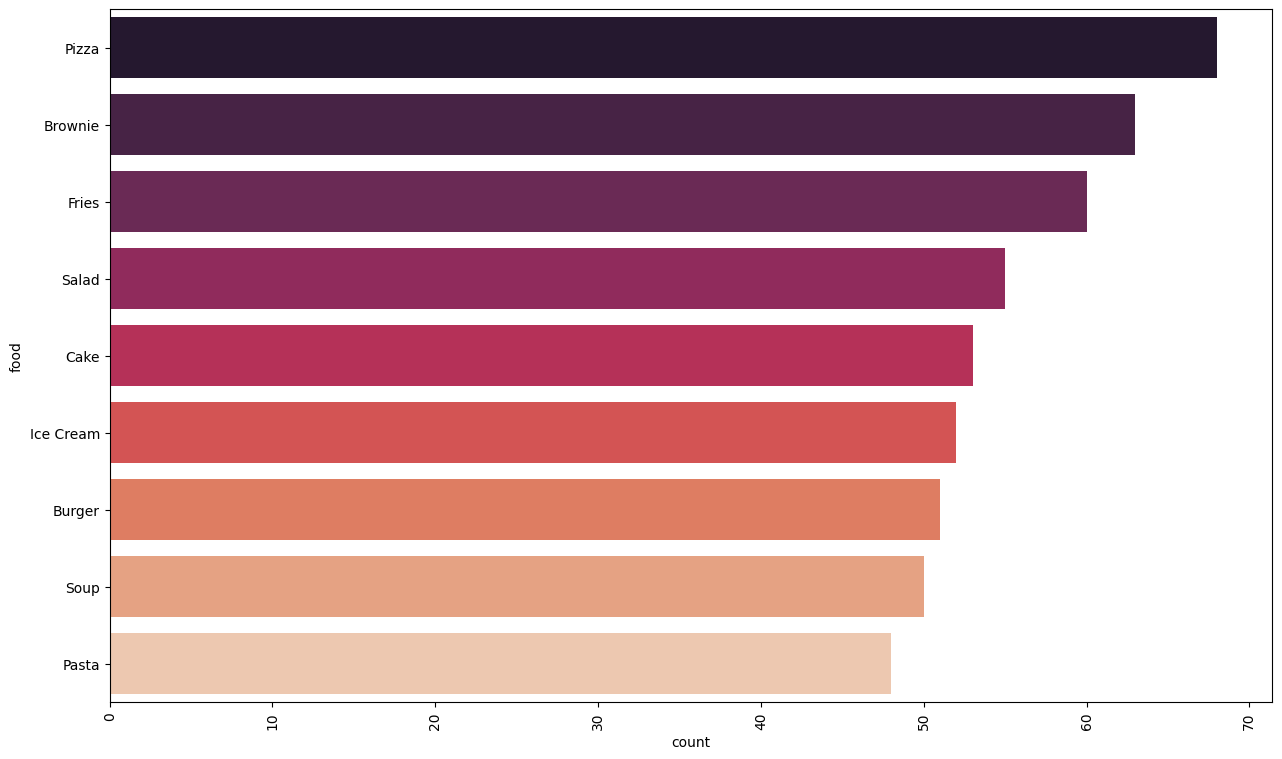

In [6]:
plt.figure(figsize=(15, 9))
sns.barplot(x = food['count'], y=food['food'], palette='rocket')
plt.xticks(rotation= 90)
plt.show

In [7]:
payment = data['Payment Method'].value_counts().reset_index()
payment.columns = ['payment', 'count']
payment

,payment,count
0,Cash,132
1,Credit Card,128
2,Online Payment,121
3,Debit Card,119


C:\Users\sho_taso\AppData\Local\Temp\ipykernel_6704\2234665096.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = payment['count'], y = payment['payment'], palette='rocket')


<function matplotlib.pyplot.show(close=None, block=None)>

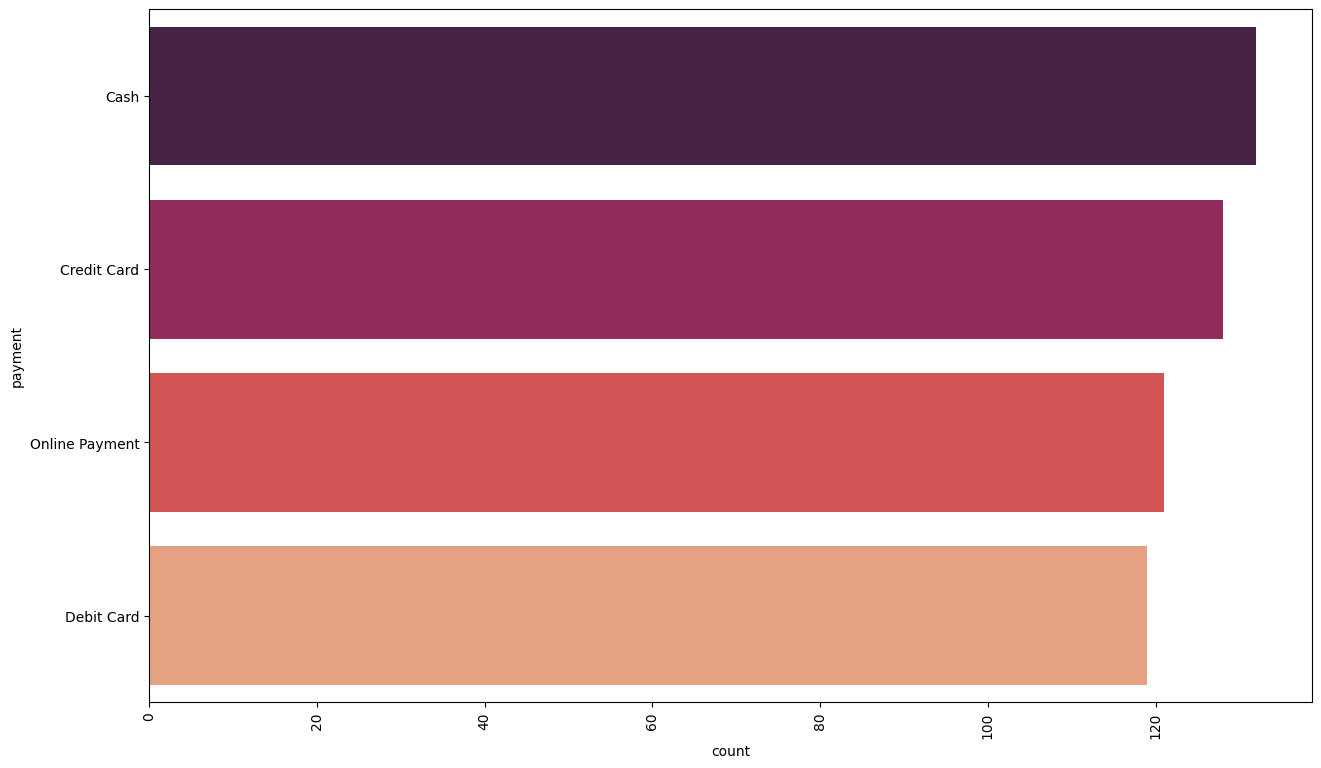

In [8]:
plt.figure(figsize=(15, 9))
sns.barplot(x = payment['count'], y = payment['payment'], palette='rocket')
plt.xticks(rotation= 90)
plt.show

In [9]:
data['Order Time'] = pd.to_datetime(data['Order Time'])
data

,Order ID,Customer Name,Food Item,Category,Quantity,Price,Payment Method,Order Time
0,2268,Mary Vega DDS,Pasta,Main,5,17,Cash,2025-02-02 14:28:41
1,3082,Brandon Myers,Brownie,Dessert,4,17,Debit Card,2025-06-08 10:57:47
2,3160,Margaret Wells,Pasta,Main,1,3,Credit Card,2025-03-04 07:41:41
3,1272,Michael Matthews,Pasta,Main,5,2,Online Payment,2025-05-15 12:43:45
4,9447,Connor Williams,Soup,Starter,1,12,Cash,2025-03-15 14:25:56
...,...,...,...,...,...,...,...,...
495,6323,Alyssa Anthony,Pizza,Main,1,21,Cash,2025-01-15 19:21:02
496,9836,Jerry Pineda,Soup,Starter,3,16,Debit Card,2025-07-15 15:00:19
497,1202,Brandy Smith,Pasta,Main,2,9,Credit Card,2025-08-03 23:47:28
498,7876,Ivan Haynes,Soup,Starter,5,21,Credit Card,2025-07-23 08:10:06


In [10]:
busiest = data.groupby(data['Order Time'].dt.hour).size().reset_index(name='count')
busiest

,Order Time,count
0,0,21
1,1,16
2,2,17
3,3,20
4,4,19
5,5,25
6,6,16
7,7,24
8,8,28
9,9,23


In [11]:
busiest_hour = busiest.loc[busiest['count'].idxmax(), 'Order Time']
busiest_hour

np.int32(12)

In [12]:
busiest['color'] = ['red' if hour == busiest_hour else 'skyblue' for hour in busiest['Order Time']]


C:\Users\sho_taso\AppData\Local\Temp\ipykernel_6704\3615184394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = busiest, x = 'Order Time', y = 'count', palette= 'rocket')


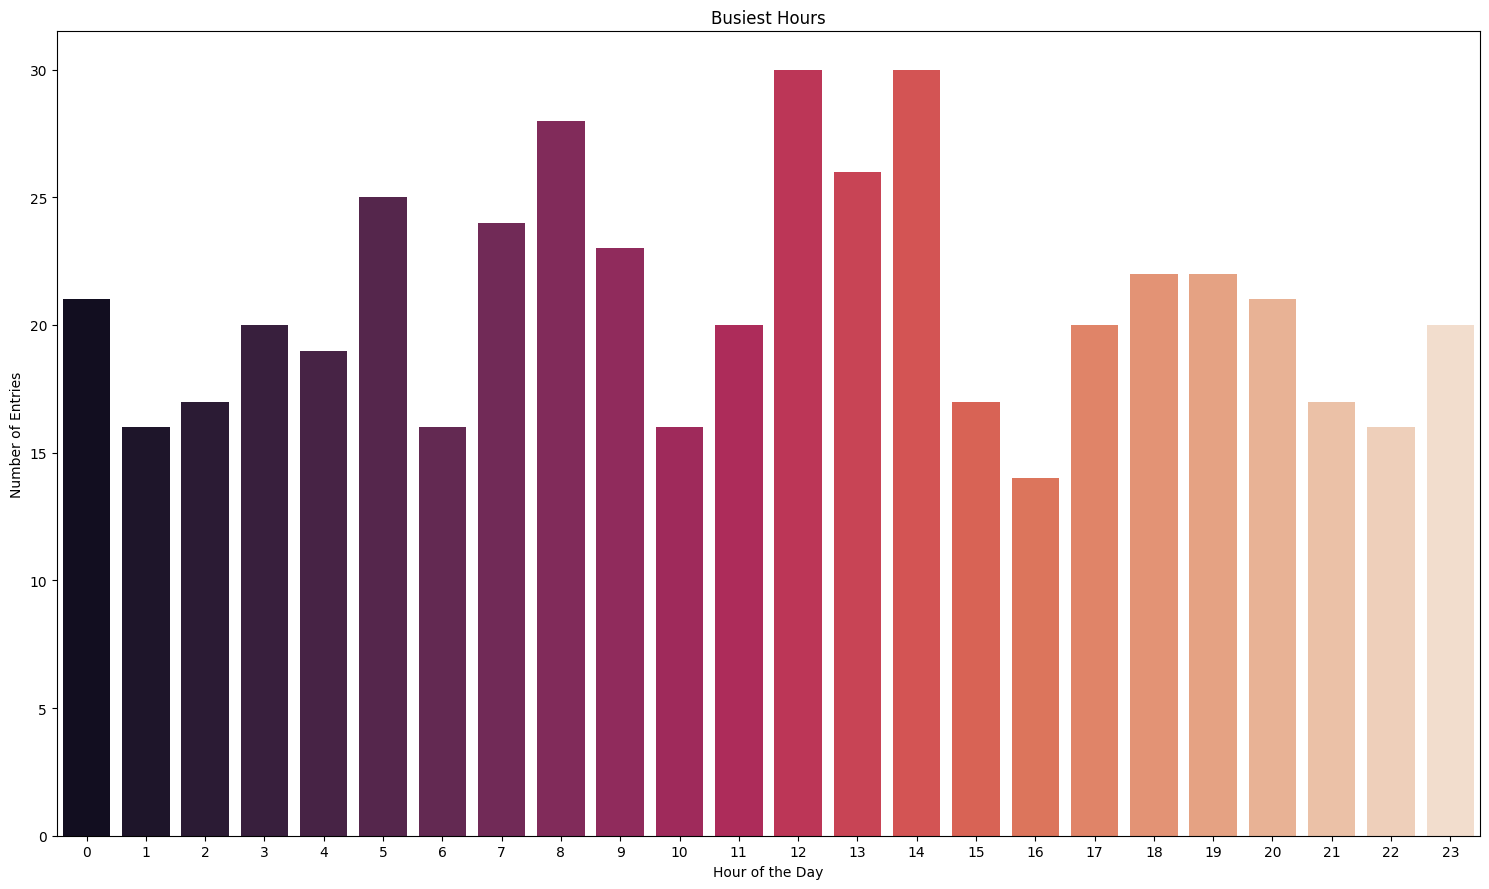

In [13]:
plt.figure(figsize=(15, 9))
sns.barplot(data = busiest, x = 'Order Time', y = 'count', palette= 'rocket')
plt.title("Busiest Hours")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Entries")
plt.tight_layout()
plt.show()